In [1]:
import pandas as pd
from pathlib import Path

DATA_PATH = Path(r"C:\Users\DELL\OneDrive\Desktop\predictive-maintenance\data\ai4i2020.csv")

print("Data path   :", DATA_PATH)
print("File exists:", DATA_PATH.exists())

df = pd.read_csv(DATA_PATH)
df.head()

Data path   : C:\Users\DELL\OneDrive\Desktop\predictive-maintenance\data\ai4i2020.csv
File exists: True


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [2]:
df.shape

(10000, 14)

In [3]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='str')

In [4]:
df.dtypes

UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

In [5]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [6]:
print(f"Duplicates: {df.duplicated().sum()}")

Duplicates: 0


In [7]:
df['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [8]:
df['Machine failure'].value_counts(normalize=True) * 100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

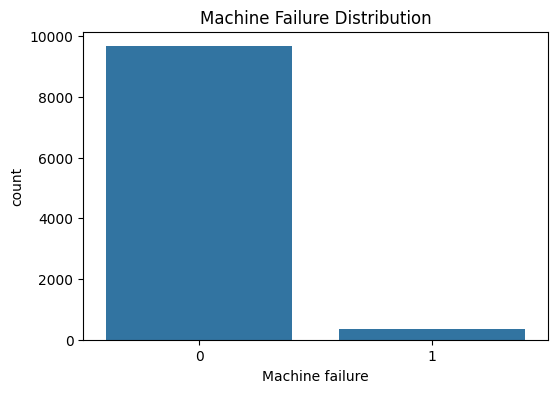

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='Machine failure', data=df)
plt.title('Machine Failure Distribution')
plt.show()


In [10]:
df['Type'].value_counts()


Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [11]:
pd.crosstab(df['Type'], df['Machine failure'], normalize='index') * 100


Machine failure,0,1
Type,,
H,97.906281,2.093719
L,96.083333,3.916667
M,97.230564,2.769436


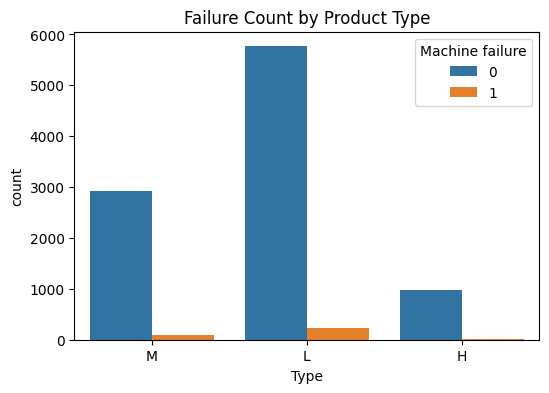

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='Type', hue='Machine failure', data=df)
plt.title('Failure Count by Product Type')
plt.show()

In [13]:
num_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]
df[num_cols].describe()



,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000
std,2.000259,1.483734,179.284096,9.968934,63.654147
min,295.300000,305.700000,1168.000000,3.800000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000


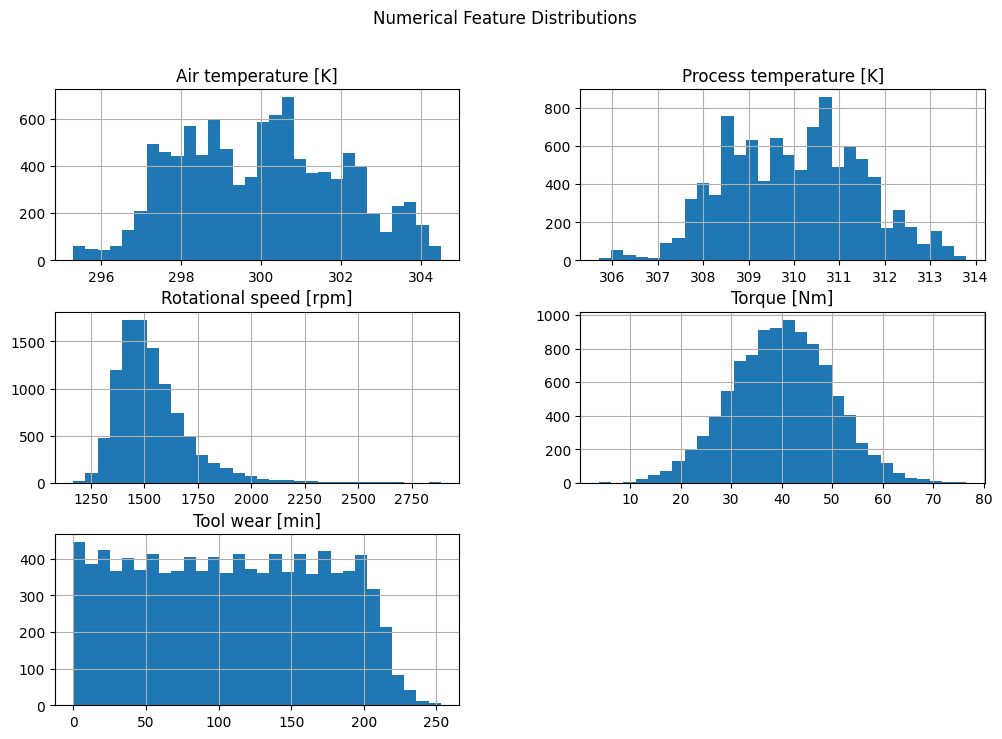

In [14]:
df[num_cols].hist(figsize=(12,8), bins=30)
plt.suptitle("Numerical Feature Distributions")
plt.show()


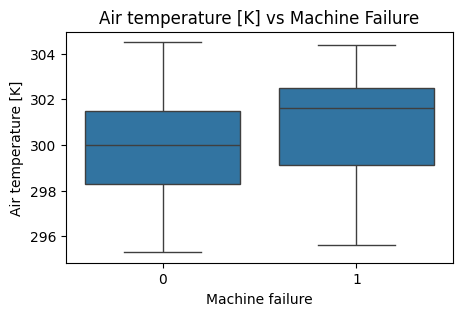

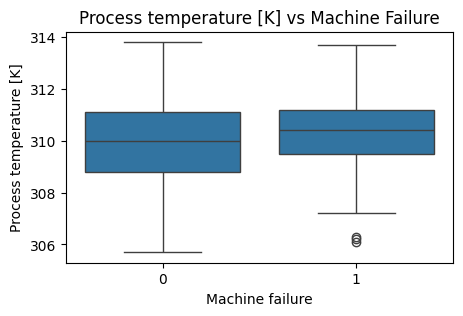

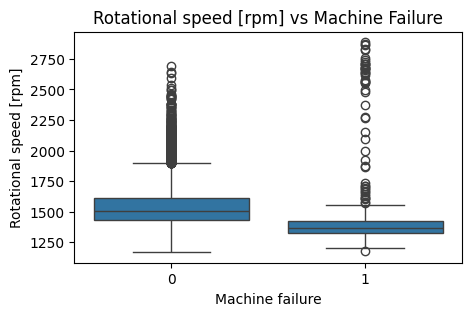

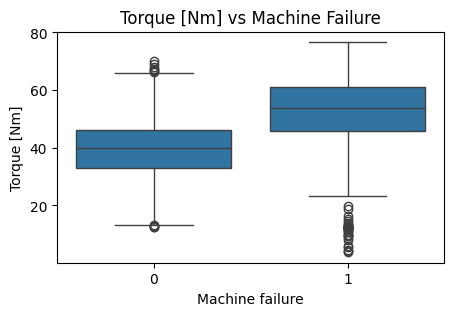

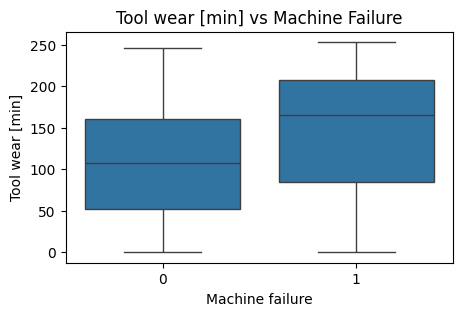

In [15]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x='Machine failure', y=col, data=df)
    plt.title(f'{col} vs Machine Failure')
    plt.show()


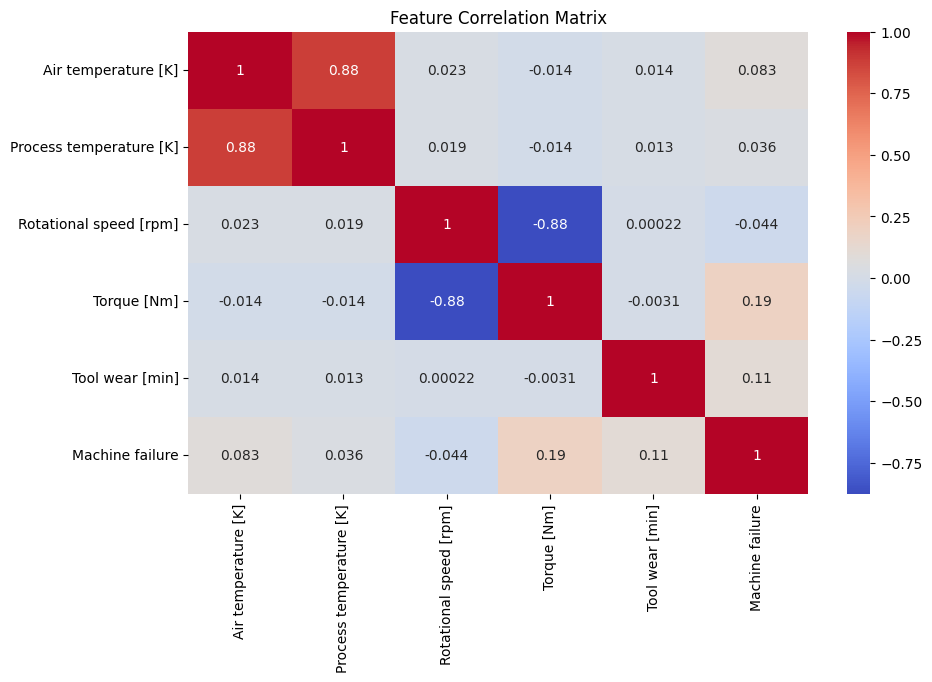

In [16]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols + ['Machine failure']].corr(), 
            annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()


In [17]:
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
df[failure_cols].sum()


TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

## Data Preprocessing

In [18]:
df_preprocessed = df.copy()

In [19]:
df_preprocessed.drop(columns=['UDI', 'Product ID'], inplace=True)


In [20]:
leakage_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
df_preprocessed.drop(columns=leakage_cols, inplace=True)


In [21]:
df_preprocessed.columns


Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure'],
      dtype='str')

In [22]:
y = df_preprocessed['Machine failure']


In [23]:
X = df_preprocessed.drop(columns=['Machine failure'])


In [24]:
X.shape, y.shape


((10000, 6), (10000,))

In [25]:
X['Type'].unique()


<StringArray>
['M', 'L', 'H']
Length: 3, dtype: str

In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
X['Type'] = le.fit_transform(X['Type'])


In [27]:
dict(zip(le.classes_, le.transform(le.classes_)))


{'H': np.int64(0), 'L': np.int64(1), 'M': np.int64(2)}

In [28]:
X.dtypes


Type                         int64
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
dtype: object

In [29]:
X.head()


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,2,298.1,308.6,1551,42.8,0
1,1,298.2,308.7,1408,46.3,3
2,1,298.1,308.5,1498,49.4,5
3,1,298.2,308.6,1433,39.5,7
4,1,298.2,308.7,1408,40.0,9


In [30]:
y.value_counts()


Machine failure
0    9661
1     339
Name: count, dtype: int64

## Feature Engineering

In [31]:
X['Temp_diff'] = X['Process temperature [K]'] - X['Air temperature [K]']


In [32]:
X[['Air temperature [K]', 'Process temperature [K]', 'Temp_diff']].head()


,Air temperature [K],Process temperature [K],Temp_diff
0,298.1,308.6,10.5
1,298.2,308.7,10.5
2,298.1,308.5,10.4
3,298.2,308.6,10.4
4,298.2,308.7,10.5


In [33]:
X['Power_load'] = X['Torque [Nm]'] * X['Rotational speed [rpm]']


In [34]:
X['Wear_load_ratio'] = X['Tool wear [min]'] / (X['Torque [Nm]'] + 1)


In [35]:
X.shape


(10000, 9)

In [36]:
X.columns


Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temp_diff',
       'Power_load', 'Wear_load_ratio'],
      dtype='str')

In [37]:
X[['Temp_diff', 'Power_load', 'Wear_load_ratio']].describe()


,Temp_diff,Power_load,Wear_load_ratio
count,10000.000000,10000.000000,10000.000000
mean,10.000630,59967.147040,2.832776
std,1.001094,10193.093881,2.001622
min,7.600000,10966.800000,0.000000
25%,9.300000,53105.400000,1.297960
50%,9.800000,59883.900000,2.606000
75%,11.000000,66873.750000,4.036758
max,12.100000,99980.400000,32.272727


## Train–Test Split

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [39]:
X_train.shape, X_test.shape


((8000, 9), (2000, 9))

In [40]:
y_train.shape, y_test.shape


((8000,), (2000,))

In [41]:
print("Train set:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest set:")
print(y_test.value_counts(normalize=True) * 100)


Train set:
Machine failure
0    96.6125
1     3.3875
Name: proportion, dtype: float64

Test set:
Machine failure
0    96.6
1     3.4
Name: proportion, dtype: float64
